# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

In [15]:
print("Who: Real Estate investment analysts and fund managers.")
print("What: To understand what overall cities are growing in value and not against the national average.")
print("How: Utilizing a historical data set from Zillow, we will create a time-series visualization that compares the US Average vs the growth of our major cities.")

Who: Real Estate investment analysts and fund managers.
What: To understand what overall cities are growing in value and not against the national average.
How: Utilizing a historical data set from Zillow, we will create a time-series visualization that compares the US Average vs the growth of our major cities.


# 3. Homework - work with your own data

In [16]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# try:
#     from google.colab import drive  # Colab only
#     drive.mount('/content/drive')
# except ModuleNotFoundError:
#     # not running in Colab; skip
#     pass


# Load the dataset
df = pd.read_csv('Zillow_Data.csv')

# df = pd.read_csv('/content/drive/MyDrive/Zillow_Data.csv')
# For Google Drive to Collab connection

# Summarize the datasets
print("\nData Info:")
df.info()

print("\n\nData Description:")
print(df.describe())

# Chekcing for duplicate values
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate RegionIDs:", df['RegionID'].duplicated().sum())

# Mean, Median, and Mode of the most recent column
latest_col = df.columns[-1]
print(f"\nStats for {latest_col}:")
print("Mean:", df[latest_col].mean())
print("Median:", df[latest_col].median())
print("Mode:", df[latest_col].mode()[0])

# Udnerstanding how many null values are in data set
print("\nTotal missing values:", df.isnull().sum().sum())

# Helping to fill in null data with means
date_cols = [col for col in df.columns if '-' in col]
df_filled = df.copy()
df_filled[date_cols] = df_filled[date_cols].fillna(df_filled[date_cols].mean())

# Understanding what inconsisten data there is. In this case, looking at negative prices
negative_prices = (df_filled[date_cols] < 0).any().any()
print("\nAre there negative prices?:", negative_prices)

df_encoded = pd.get_dummies(df_filled, columns=['RegionType'])

# Understanding Class Imalance
print("\nState Counts (Class Imbalance Check):")
print(df['StateName'].value_counts().head())


print("\nConclusions:")
print("Are the data usable? Yes, overall the data set is complete and useable.")
print("Do you need to modify the data? Yes, I had to made some slight adjustments to the data to smooth it out, so it is prepped for analysis. One example was filling in null values with the mean of that segment.")
print("Is there any class imbalance? Yes, one class imbalance I found was that Texas has significantly more regions than other states.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Columns: 317 entries, RegionID to 2025-12-31
dtypes: float64(312), int64(2), object(3)
memory usage: 2.2+ MB


Data Description:
            RegionID    SizeRank     2000-01-31     2000-02-29     2000-03-31  \
count     895.000000  895.000000     431.000000     432.000000     433.000000   
mean   412099.672626  461.751955  107916.304942  108092.825680  108247.287725   
std     78377.355083  268.710532   45951.603862   46062.429170   46249.087615   
min    102001.000000    0.000000   44913.398304   44939.375150   45044.146459   
25%    394546.000000  230.500000   77126.564031   77214.588911   77322.892728   
50%    394795.000000  460.000000   96846.776965   97044.078719   97087.943497   
75%    395044.500000  689.500000  124414.624175  124560.364224  124791.776753   
max    753

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

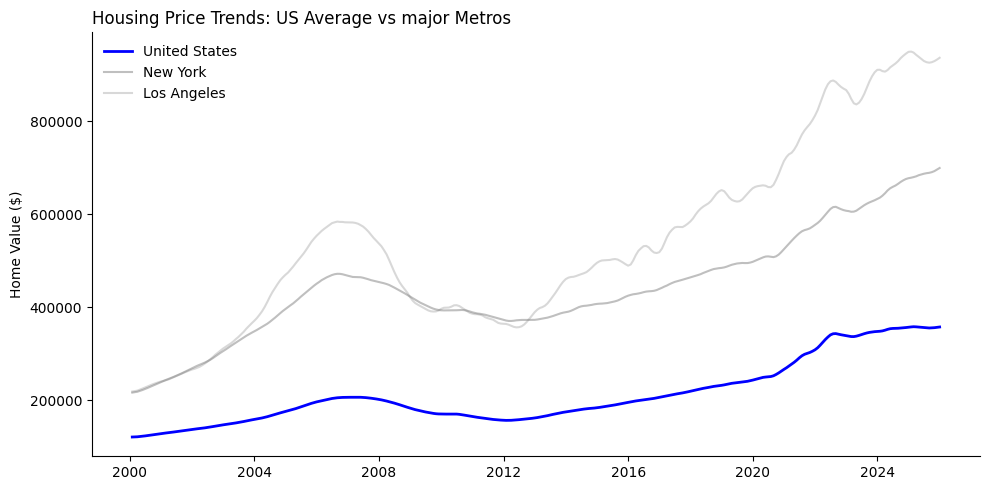

In [11]:
import matplotlib.pyplot as plt

plot_data = df[df['SizeRank'].isin([0, 1, 2])].copy()
plot_data = plot_data.set_index('RegionName')[date_cols].T
plot_data.index = pd.to_datetime(plot_data.index)

plt.figure(figsize=(10, 5))

plt.plot(plot_data.index, plot_data['United States'], color='blue', linewidth=2, label='United States')
plt.plot(plot_data.index, plot_data['New York, NY'], color='gray', alpha=0.5, label='New York')
plt.plot(plot_data.index, plot_data['Los Angeles, CA'], color='gray', alpha=0.3, label='Los Angeles')

plt.title('Housing Price Trends: US Average vs major Metros', loc='left')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylabel('Home Value ($)')
plt.legend(frameon=False)

plt.tight_layout()
plt.show()